# Final Evaluation (Validation + Test)

This notebook sweeps thresholds on validation data, then applies the best threshold to test for the final MAP@5.
It runs the same flow for the baseline, ArcFace, and Triplet experiments.

## Setup & Imports

Load evaluation utilities and register the experiment checkpoints to run.

In [1]:
import numpy as np
import torch

from config import ExperimentConfig
from dataset import (
    build_dataloaders,
    build_retrieval_eval_loaders,
    build_test_loader,
    prepare_data,
 )
from final_evaluation import (
    calculate_map5,
    evaluate_base_metrics,
    get_classifier_predictions,
    get_retrieval_predictions,
    insert_new_whale,
    sweep_thresholds,
 )
from models import build_model
from visualization import plot_evaluation


# Experiment artifacts to evaluate.
experiments = {
    "baseline_cross_entropy": {
        "config": "experiments/20260524_230915_baseline_effnetb5_cross_entrop_a55bddfe/config.json",
        "checkpoint": "experiments/20260524_230915_baseline_effnetb5_cross_entrop_a55bddfe/checkpoints/best.pth",
    },
    "arcface": {
        "config": "experiments/20260525_213055_arcface_effnetb5_a3fe4406/config.json",
        "checkpoint": "experiments/20260525_213055_arcface_effnetb5_a3fe4406/checkpoints/best.pth",
    },
}

/root/ML4CV/models.py:65: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


## Loaders + Checkpoints

Helper to load config, data splits, loaders, and model weights per experiment.

In [2]:
from dataset import get_eval_config_and_data


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_experiment(info):
    # Load config/data and prepare eval loaders.
    data_config, data = get_eval_config_and_data()
    gallery_loader, val_loader = build_retrieval_eval_loaders(data_config, data)
    test_loader = build_test_loader(data_config, data)

    # Load model weights.
    config = ExperimentConfig.load(info["config"])
    config.include_new_whale_in_val = True

    checkpoint = torch.load(info["checkpoint"], map_location=device, weights_only=False)
    extra = checkpoint.get("extra", {})
    num_classes = extra.get("num_classes", data["num_classes"])

    model = build_model(config, num_classes=num_classes, device=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    return config, data, model, gallery_loader, val_loader, test_loader

## Validation Sweep

Find the best open-set threshold on the validation split.

In [3]:
results = {}

for name, info in experiments.items():
    print(f"\n=== {name} ===")
    config, data, model, gallery_loader, val_loader, _ = load_experiment(info)

    # Validation predictions for threshold sweep.
    if config.head_type == "linear":
        scores, preds, labels = get_classifier_predictions(model, val_loader, device)
    else:
        scores, preds, labels = get_retrieval_predictions(
            model, gallery_loader, val_loader, device
        )

    base_metrics = evaluate_base_metrics(scores, preds, labels)
    thresholds, map_scores, best_t, best_map = sweep_thresholds(scores, preds, labels)

    results[name] = {
        "base_metrics": base_metrics,
        "best_threshold": best_t,
        "best_map5": best_map,
        "thresholds": thresholds,
        "map_scores": map_scores,
    }

    print("Base Validation Metrics:", base_metrics)
    print(f"Optimal Validation Threshold: {best_t:.3f} -> MAP@5: {best_map:.4f}")


=== baseline_cross_entropy ===
Split (seed=42): train=7136 (4250 cls), val=1102 (405 new_whale), test=1612 (405 new_whale)


Extracting Classifier Preds:   0%|          | 0/46 [00:00<?, ?it/s]

Sweeping Thresholds:   0%|          | 0/100 [00:00<?, ?it/s]

Base Validation Metrics: {'known_recall@1': 0.615494966506958, 'known_recall@5': 0.7446197867393494, 'mean_known_conf': 0.7489198446273804, 'mean_new_whale_conf': 0.6408734321594238}
Optimal Validation Threshold: 0.798 -> MAP@5: 0.6742

=== arcface ===
Split (seed=42): train=7136 (4250 cls), val=1102 (405 new_whale), test=1612 (405 new_whale)


  Extracting embeddings:   0%|          | 0/298 [00:00<?, ?it/s]

  Extracting embeddings:   0%|          | 0/46 [00:00<?, ?it/s]

Computing k-NN:   0%|          | 0/3 [00:00<?, ?it/s]

Sweeping Thresholds:   0%|          | 0/100 [00:00<?, ?it/s]

Base Validation Metrics: {'known_recall@1': 0.659971296787262, 'known_recall@5': 0.760401725769043, 'mean_known_conf': 0.732208251953125, 'mean_new_whale_conf': 0.6920926570892334}
Optimal Validation Threshold: 0.658 -> MAP@5: 0.6882


## Test Evaluation

Apply the validation threshold to test and report the final MAP@5.


=== baseline_cross_entropy (test) ===


Split (seed=42): train=7136 (4250 cls), val=1102 (405 new_whale), test=1612 (405 new_whale)


Extracting Classifier Preds:   0%|          | 0/68 [00:00<?, ?it/s]

Test Base Metrics: {'known_recall@1': 0.5385252833366394, 'known_recall@5': 0.6578293442726135, 'mean_known_conf': 0.7073614001274109, 'mean_new_whale_conf': 0.6531258821487427}
Final Test MAP@5: 0.5860


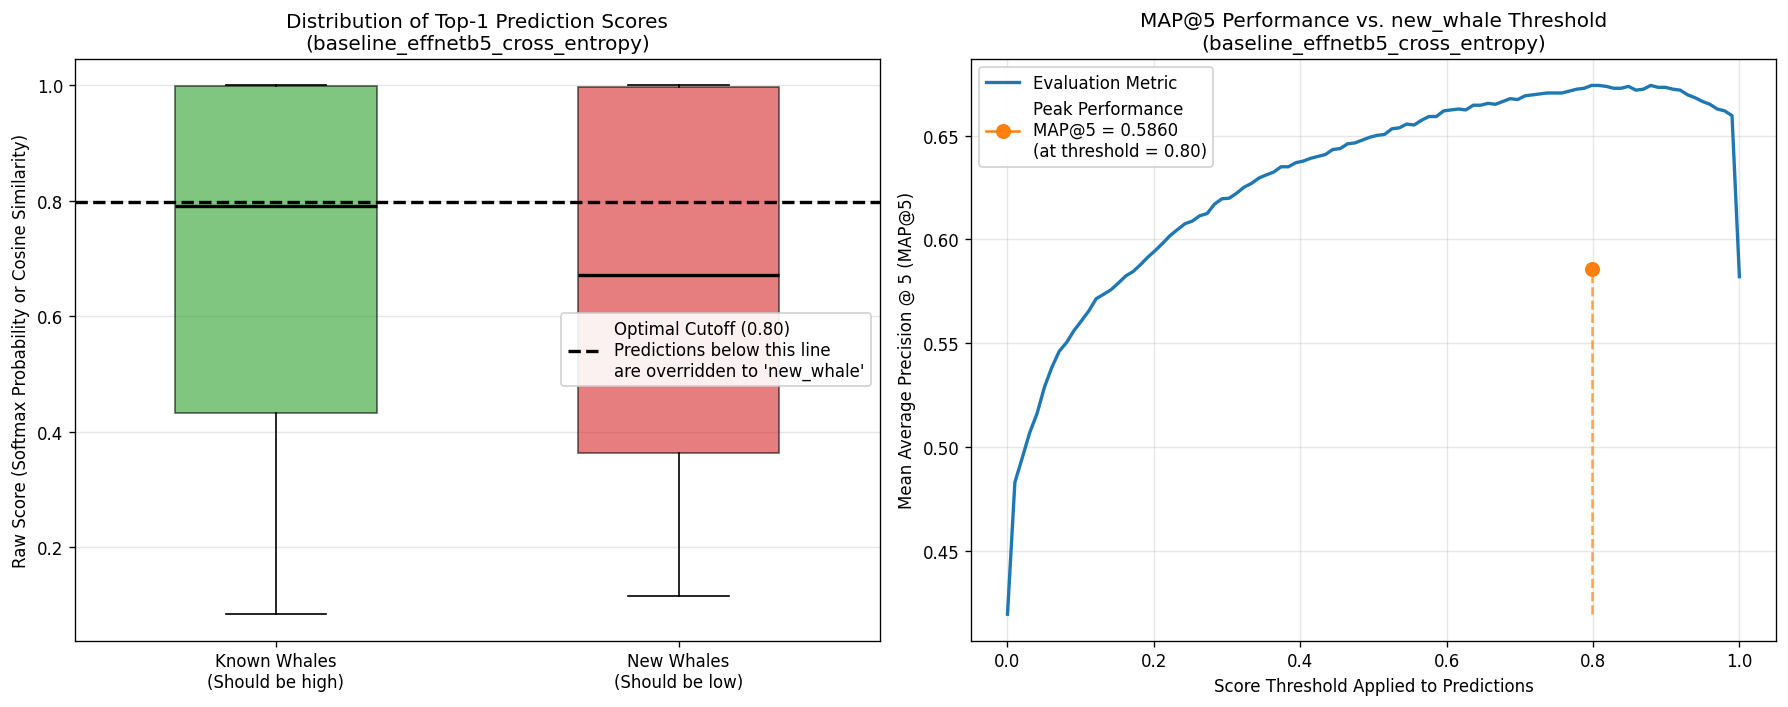


=== arcface (test) ===
Split (seed=42): train=7136 (4250 cls), val=1102 (405 new_whale), test=1612 (405 new_whale)


  Extracting embeddings:   0%|          | 0/298 [00:00<?, ?it/s]

  Extracting embeddings:   0%|          | 0/68 [00:00<?, ?it/s]

Computing k-NN:   0%|          | 0/4 [00:00<?, ?it/s]

Test Base Metrics: {'known_recall@1': 0.5898922681808472, 'known_recall@5': 0.6893123388290405, 'mean_known_conf': 0.7141655087471008, 'mean_new_whale_conf': 0.6983270049095154}
Final Test MAP@5: 0.6139


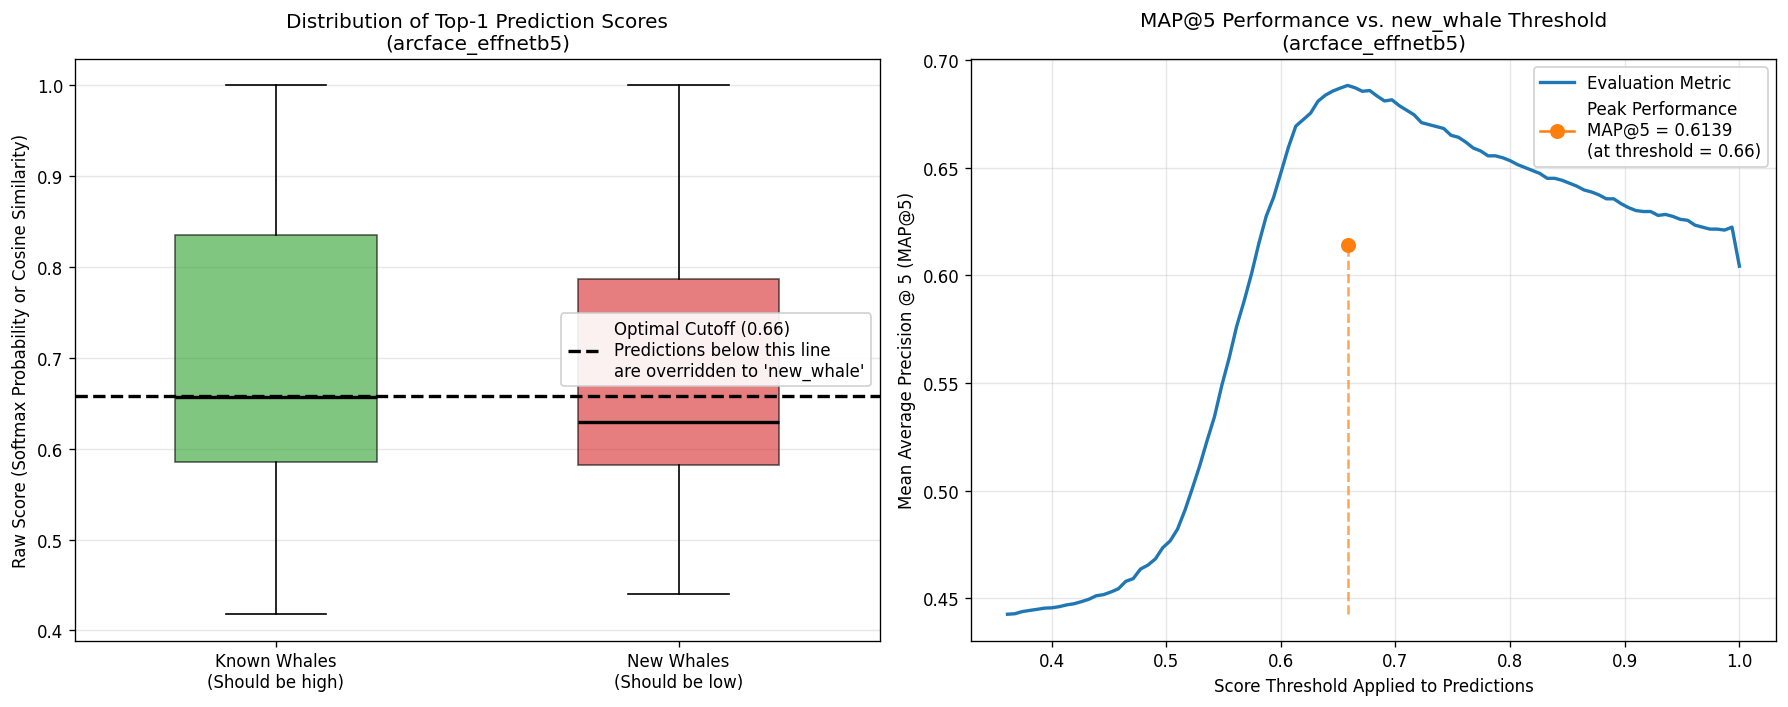

In [4]:
for name, info in experiments.items():
    print(f"\n=== {name} (test) ===")
    config, data, model, gallery_loader, _, test_loader = load_experiment(info)

    if config.head_type == "linear":
        test_scores, test_preds, test_labels = get_classifier_predictions(
            model, test_loader, device
        )
    else:
        test_scores, test_preds, test_labels = get_retrieval_predictions(
            model, gallery_loader, test_loader, device
        )

    base_test_metrics = evaluate_base_metrics(test_scores, test_preds, test_labels)

    test_preds_np = test_preds.cpu().numpy()
    test_scores_np = test_scores.cpu().numpy()
    test_labels_np = test_labels.cpu().numpy()
    best_threshold = results[name]["best_threshold"]

    # Apply validation threshold to test predictions.
    final_test_preds = np.array([
        insert_new_whale(p, s, best_threshold)
        for p, s in zip(test_preds_np, test_scores_np)
    ])

    final_test_map5 = calculate_map5(final_test_preds, test_labels_np)

    results[name]["test_base_metrics"] = base_test_metrics
    results[name]["final_test_map5"] = final_test_map5

    print("Test Base Metrics:", base_test_metrics)
    print(f"Final Test MAP@5: {final_test_map5:.4f}")

    plot_evaluation(
        scores=test_scores,
        labels=test_labels,
        thresholds=results[name]["thresholds"],
        map5_scores=results[name]["map_scores"],
        best_threshold=best_threshold,
        best_map5=final_test_map5,
        model_name=config.experiment_name or name,
    )